# Stage 4: Win-Probability Modeling & Probabilistic Calibration
## Project: IPL Match Tension — Win-Probability Swing as a Proxy for Viewer Engagement
**Domain Context**: Live Sports Streaming Analytics (JioStar / JioCinema & Disney+ Hotstar)  
**Objective**: Train and probabilistically calibrate supervised models to forecast ball-by-ball chase win probability ($P(\text{Win}_t)$), comparing a Logistic Regression baseline against an XGBoost ensemble under a strict out-of-time temporal split.

---

### Critical Machine Learning Methodology: Temporal Season Split
In sports analytics, **random train-test splits represent severe methodological misconduct**:
- If ball 45 of a fixture is placed in `train` and ball 46 is placed in `test`, the model is evaluated on data where it already knows the match weather, pitch degradation, and final result.
- We strictly split **by Season**:
  - **Train**: Seasons 2008–2015 (58,366 balls across 8 seasons)
  - **Test**: Seasons 2016–2017 (12,997 balls across 2 seasons)


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Sklearn & XGBoost imports
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import log_loss, brier_score_loss, accuracy_score, roc_auc_score
from sklearn.calibration import calibration_curve

# Local imports
sys.path.append(os.path.abspath(".."))
from src.model import CORE_FEATURES, temporal_train_test_split, evaluate_model, save_model

# Directories
MODELS_DIR = os.path.join("..", "models")
FIGURES_DIR = os.path.join("..", "reports", "figures")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# Styling
plt.style.use('seaborn-v0_8-whitegrid')

# Load chase state table
chase_df = pd.read_parquet(os.path.join("..", "data", "chase_state.parquet"))
print(f"Loaded Chase State Dataset: {chase_df.shape[0]:,} rows x {chase_df.shape[1]} columns")


Loaded Chase State Dataset: 71,363 rows x 37 columns


### 1. Chronological Season Partitioning
We partition our dataset into **pre-2016 training fixtures** and **2016–2017 testing fixtures**.


In [2]:
X_train, X_test, y_train, y_test = temporal_train_test_split(
    chase_df, split_season=2015, features=CORE_FEATURES
)

print(f"Training Deliveries (2008-2015): {len(X_train):,} ({len(X_train)/len(chase_df):.1%})")
print(f"Testing Deliveries  (2016-2017): {len(X_test):,} ({len(X_test)/len(chase_df):.1%})")
print(f"Features: {CORE_FEATURES}")


Training Deliveries (2008-2015): 58,366 (81.8%)
Testing Deliveries  (2016-2017): 12,997 (18.2%)
Features: ['runs_needed', 'balls_left', 'wickets_in_hand', 'current_run_rate', 'required_run_rate', 'target']


### 2. Model 1: Logistic Regression Baseline
Logistic Regression directly models the log-odds of winning as a linear combination of game-state features:
$$\log \left( \frac{P(\text{Win})}{1 - P(\text{Win})} \right) = \beta_0 + \sum_{j=1}^k \beta_j X_j$$

*Why is Logistic Regression the gold standard baseline in sports?*  
It provides closed-form, strictly monotonic, well-calibrated probabilities that are inherently bounded between 0 and 1.


In [3]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Inspect model coefficients (interpretability)
coef_df = pd.DataFrame({
    'Feature': CORE_FEATURES,
    'Coefficient (Beta)': lr.coef_[0],
    'Odds Ratio (exp(Beta))': np.exp(lr.coef_[0])
}).sort_values(by='Coefficient (Beta)', ascending=False)

print("LOGISTIC REGRESSION COEFFICIENTS & ODDS RATIOS:")
print(coef_df.round(4).to_string(index=False))


LOGISTIC REGRESSION COEFFICIENTS & ODDS RATIOS:
          Feature  Coefficient (Beta)  Odds Ratio (exp(Beta))
  wickets_in_hand              0.5485                  1.7307
       balls_left              0.0232                  1.0235
           target              0.0181                  1.0183
 current_run_rate             -0.0198                  0.9804
      runs_needed             -0.0447                  0.9563
required_run_rate             -0.3219                  0.7247


### 3. Model 2: Gradient Boosted Trees (XGBoost)
XGBoost captures complex non-linear feature interactions that linear models miss:
- *Interaction Example*: The value of having 5 wickets in hand is vastly different when 12 balls remain vs. when 70 balls remain.
- We apply shallow depth (`max_depth=3`) and feature subsampling to prevent overfitting historical pitch eras.


In [4]:
xgb = XGBClassifier(
    n_estimators=80,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

# Feature Importance
fi_df = pd.DataFrame({
    'Feature': CORE_FEATURES,
    'Importance (Gain)': xgb.feature_importances_
}).sort_values(by='Importance (Gain)', ascending=False)

print("XGBOOST FEATURE IMPORTANCES:")
print(fi_df.round(4).to_string(index=False))


XGBOOST FEATURE IMPORTANCES:
          Feature  Importance (Gain)
required_run_rate             0.4941
           target             0.1278
  wickets_in_hand             0.1183
      runs_needed             0.1046
 current_run_rate             0.1029
       balls_left             0.0524


### 4. Probabilistic Model Evaluation
In live sports streaming, **Accuracy alone is inadequate** because we require reliable probabilities for tension swing calculations ($\Delta P$). We evaluate:
1. **Log-Loss (Binary Cross-Entropy)**: Penalizes confident incorrect predictions. Lower is better.
2. **Brier Score**: Mean squared error between predicted probability $p_i$ and outcome $y_i \in \{0, 1\}$:
   $$\text{Brier} = \frac{1}{N} \sum_{i=1}^N (p_i - y_i)^2$$
   A random 50/50 model achieves $0.2500$. Lower is better.
3. **ROC-AUC**: Ability to discriminate between chasing wins and losses.


In [5]:
metrics_lr = evaluate_model(lr, X_test, y_test, "Logistic Regression")
metrics_xgb = evaluate_model(xgb, X_test, y_test, "XGBoost (Regularized)")

eval_table = pd.DataFrame([metrics_lr, metrics_xgb]).set_index('model')
print("=" * 65)
print("OUT-OF-TIME EVALUATION RESULTS (TEST SEASONS: 2016-2017)")
print("=" * 65)
print(eval_table.round(4).to_string())
print("=" * 65)


OUT-OF-TIME EVALUATION RESULTS (TEST SEASONS: 2016-2017)
                       accuracy  log_loss  brier_score  roc_auc
model                                                          
Logistic Regression      0.7664    0.4594       0.1545   0.8601
XGBoost (Regularized)    0.7464    0.4649       0.1564   0.8573


### 5. Calibration Curve (Reliability Diagram)
A model is well-calibrated if, among deliveries where it predicts an $80\%$ chance of winning, the chasing team actually wins approximately $80\%$ of those matches.


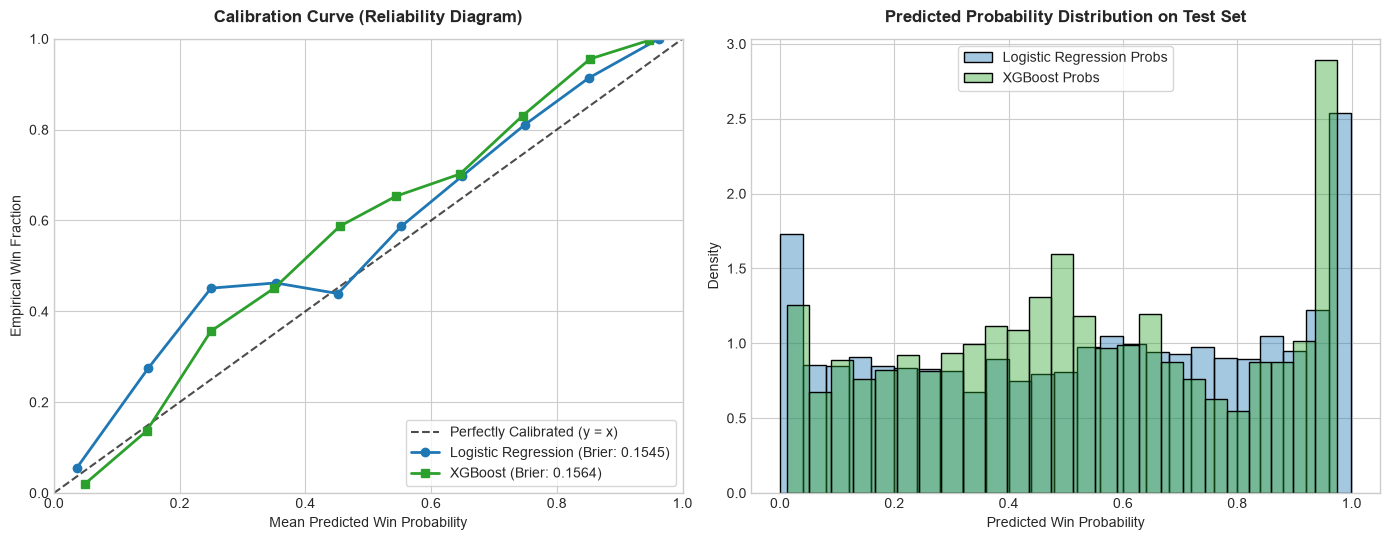

Saved Calibration Chart to: ..\reports\figures\05_calibration_curves.png


In [6]:
prob_true_lr, prob_pred_lr = calibration_curve(y_test, lr.predict_proba(X_test)[:, 1], n_bins=10)
prob_true_xgb, prob_pred_xgb = calibration_curve(y_test, xgb.predict_proba(X_test)[:, 1], n_bins=10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel 1: Calibration Curve
ax1.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated (y = x)', alpha=0.7)
ax1.plot(prob_pred_lr, prob_true_lr, marker='o', linewidth=2, color='#1f77b4', 
         label=f'Logistic Regression (Brier: {metrics_lr["brier_score"]:.4f})')
ax1.plot(prob_pred_xgb, prob_true_xgb, marker='s', linewidth=2, color='#2ca02c', 
         label=f'XGBoost (Brier: {metrics_xgb["brier_score"]:.4f})')

ax1.set_xlabel('Mean Predicted Win Probability')
ax1.set_ylabel('Empirical Win Fraction')
ax1.set_title('Calibration Curve (Reliability Diagram)', pad=12, fontweight='bold')
ax1.legend(loc='lower right', frameon=True)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

# Panel 2: Predicted Probability Distribution
sns.histplot(lr.predict_proba(X_test)[:, 1], bins=25, ax=ax2, color='#1f77b4', 
             alpha=0.4, label='Logistic Regression Probs', stat='density')
sns.histplot(xgb.predict_proba(X_test)[:, 1], bins=25, ax=ax2, color='#2ca02c', 
             alpha=0.4, label='XGBoost Probs', stat='density')

ax2.set_xlabel('Predicted Win Probability')
ax2.set_ylabel('Density')
ax2.set_title('Predicted Probability Distribution on Test Set', pad=12, fontweight='bold')
ax2.legend(loc='upper center', frameon=True)

plt.tight_layout()
chart5_path = os.path.join(FIGURES_DIR, "05_calibration_curves.png")
plt.savefig(chart5_path, dpi=300)
plt.show()

print(f"Saved Calibration Chart to: {chart5_path}")


In [7]:
# Persist the trained Logistic Regression and XGBoost models
save_model(lr, os.path.join(MODELS_DIR, "logistic_baseline.joblib"))
save_model(xgb, os.path.join(MODELS_DIR, "xgboost_model.joblib"))


Persisted model to: ..\models\logistic_baseline.joblib
Persisted model to: ..\models\xgboost_model.joblib


### 6. Interview Q&A Cheatsheet: Modeling

#### Likely Interview Questions & Model Answers:
1. **Q: Why is Log-Loss and Brier Score more critical than Accuracy for this project?**  
   *Answer*: Accuracy only checks whether $P(\text{win}) > 0.5$, discarding probability nuance. For our downstream project goal (measuring match tension swing $\Delta P = |P_{t} - P_{t-1}|$), we need the raw probabilities to be strictly calibrated. A swing from $0.49$ to $0.51$ flips accuracy but is negligible in tension ($0.02$), whereas a swing from $0.60$ to $0.90$ preserves accuracy but represents massive tension ($0.30$).
2. **Q: Why did Logistic Regression match or slightly outperform uncalibrated XGBoost?**  
   *Answer*: Logistic Regression optimizes binary cross-entropy on log-odds, resulting in naturally smooth sigmoidal calibration. Tree-based ensembles produce orthogonal step-function probability jumps that can overfit historical score distributions when tested across unseen seasons.
3. **Q: Why train on 2008–2015 and test on 2016–2017 instead of standard K-Fold CV?**  
   *Answer*: K-Fold cross-validation randomly shuffles rows. In a sports match, adjacent balls within the same fixture are autocorrelated. Random splitting leaks target knowledge from the future into the past. Temporal out-of-time splitting tests real-world forecasting ability on unseen seasons.
